# Survival Analysis Lung Adenocarcinoma

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.utils import concordance_index

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load data
df = pd.read_excel("Luad_mskcc_2023.xlsx")
df.head()

,Study ID,Patient ID,Sample ID,Adjuvant,Adjuvant Chemotherapy,Adjuvant Immunotherapy,Adjuvant Targeted,Adjuvant Therapy,Adjuvant XRT,Adrenal Met Status (Months),...,Sample Class,Number of Samples Per Patient,Sample coverage,Sample Type,Sex,Somatic Status,TGF-Beta Pathway,TMB (nonsynonymous),TP53 Pathway,WNT Pathway
0,luad_mskcc_2023_met_organotropism,P-0000149,P-0000149-T01-IM3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Tumor,1,883.0,Metastasis,Female,Matched,No,9.982398,No,No
1,luad_mskcc_2023_met_organotropism,P-0000163,P-0000163-T02-IM3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Tumor,1,439.0,Metastasis,Female,Matched,No,3.327466,Yes,No
2,luad_mskcc_2023_met_organotropism,P-0000208,P-0000208-T01-WES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2,NaN,Primary,NaN,Matched,NaN,2.933333,NaN,NaN
3,luad_mskcc_2023_met_organotropism,P-0000208,P-0000208-T02-WES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2,NaN,Metastasis,NaN,Matched,NaN,1.600000,NaN,NaN
4,luad_mskcc_2023_met_organotropism,P-0000219,P-0000219-T01-IM3,Yes,Yes,No,No,Yes,Yes,NaN,...,Tumor,1,1033.0,Primary,Female,Matched,Yes,4.436621,No,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2653 entries, 0 to 2652
Data columns (total 94 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Study ID                                      2653 non-null   object 
 1   Patient ID                                    2653 non-null   object 
 2   Sample ID                                     2653 non-null   object 
 3   Adjuvant                                      641 non-null    object 
 4   Adjuvant Chemotherapy                         880 non-null    object 
 5   Adjuvant Immunotherapy                        880 non-null    object 
 6   Adjuvant Targeted                             880 non-null    object 
 7   Adjuvant Therapy                              603 non-null    object 
 8   Adjuvant XRT                                  880 non-null    object 
 9   Adrenal Met Status (Months)                   38 non-null     f

## Preprocessing

In [4]:
# Pilih Variabel yang relevan untuk analisis
columns_needed = [
    "Overall Survival (Months)",
    "Overall Survival Status",
    "Age at Surgery/Biopsy",
    "Sex",
    "Race Category",
    "Tobacco History",
    "TMB (nonsynonymous)",
    "Fraction Genome Altered",
    "Gene Panel",
    "Predominant Histologic Subtype",
    "Ever Met to Site: Liver",
    "Ever Met to Site: Bone",
    "Ever Met to Site: CNS",
    "Ever Met to Site: Pleura"
]

df = df[columns_needed].copy()
rename_map = {
    "TMB (nonsynonymous)": "TMB_nonsynonymous",
    "Race Category": "Race_Category",
    "Predominant Histologic Subtype": "Predominant_Histologic_Subtype",
    "Gene Panel": "Gene_Panel",
    "Tobacco History": "Tobacco_History",
    "Fraction Genome Altered": "Fraction_Genome_Altered",
    "Age at Surgery/Biopsy": "Age_at_Surgery_Biopsy",
    "Ever Met to Site: Liver": "Ever_Met_to_Site_Liver",
    "Ever Met to Site: Bone": "Ever_Met_to_Site_Bone",
    "Ever Met to Site: CNS": "Ever_Met_to_Site_CNS",
    "Ever Met to Site: Pleura": "Ever_Met_to_Site_Pleura",
}
df = df.rename(columns=rename_map)

In [5]:
df.head()

,Overall Survival (Months),Overall Survival Status,Age_at_Surgery_Biopsy,Sex,Race_Category,Tobacco_History,TMB_nonsynonymous,Fraction_Genome_Altered,Gene_Panel,Predominant_Histologic_Subtype,Ever_Met_to_Site_Liver,Ever_Met_to_Site_Bone,Ever_Met_to_Site_CNS,Ever_Met_to_Site_Pleura
0,NaN,NaN,51.254795,Female,Black,NaN,9.982398,0.2691,IMPACT341,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,38.487671,Female,White,NaN,3.327466,0.3584,IMPACT341,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,2.933333,NaN,WES,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,1.600000,NaN,WES,NaN,NaN,NaN,NaN,NaN
4,94.388007,0:LIVING,52.917808,Female,White,Ever,4.436621,0.0001,IMPACT341,Solid,0.0,1.0,0.0,0.0


In [6]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2653 entries, 0 to 2652
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Overall Survival (Months)       882 non-null    float64
 1   Overall Survival Status         882 non-null    object 
 2   Age_at_Surgery_Biopsy           2422 non-null   float64
 3   Sex                             2554 non-null   object 
 4   Race_Category                   2554 non-null   object 
 5   Tobacco_History                 882 non-null    object 
 6   TMB_nonsynonymous               2653 non-null   float64
 7   Fraction_Genome_Altered         2407 non-null   float64
 8   Gene_Panel                      2653 non-null   object 
 9   Predominant_Histologic_Subtype  641 non-null    object 
 10  Ever_Met_to_Site_Liver          766 non-null    float64
 11  Ever_Met_to_Site_Bone           766 non-null    float64
 12  Ever_Met_to_Site_CNS            76

In [7]:
# Cek missing values
df.isnull().sum()

Overall Survival (Months)         1771
Overall Survival Status           1771
Age_at_Surgery_Biopsy              231
Sex                                 99
Race_Category                       99
Tobacco_History                   1771
TMB_nonsynonymous                    0
Fraction_Genome_Altered            246
Gene_Panel                           0
Predominant_Histologic_Subtype    2012
Ever_Met_to_Site_Liver            1887
Ever_Met_to_Site_Bone             1887
Ever_Met_to_Site_CNS              1887
Ever_Met_to_Site_Pleura           1887
dtype: int64

In [8]:
# Ganti string 'NA' atau 'N/A' jadi NaN
df.replace(['NA', 'N/A', ''], np.nan, inplace=True)

# Drop semua baris yang memiliki missing pada kolom yang digunakan
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Ukuran Sampel Setelah Cleaning:", df.shape[0])

Ukuran Sampel Setelah Cleaning: 638


In [ ]:
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Overall Survival (Months)       638 non-null    float64
 1   Overall Survival Status         638 non-null    object 
 2   Age_at_Surgery_Biopsy           638 non-null    float64
 3   Sex                             638 non-null    object 
 4   Race_Category                   638 non-null    object 
 5   Tobacco_History                 638 non-null    object 
 6   TMB_nonsynonymous               638 non-null    float64
 7   Fraction_Genome_Altered         638 non-null    float64
 8   Gene_Panel                      638 non-null    object 
 9   Predominant_Histologic_Subtype  638 non-null    object 
 10  Ever_Met_to_Site_Liver          638 non-null    float64
 11  Ever_Met_to_Site_Bone           638 non-null    float64
 12  Ever_Met_to_Site_CNS            638 

In [10]:
# Encode status survival
df['Overall Survival Status'] = df['Overall Survival Status'].map({'1:DECEASED': 1, '0:LIVING': 0})

# Validasi mapping
assert df['Overall Survival Status'].isin([0, 1]).all(), "Ada nilai tidak valid di 'Overall Survival Status'"
df['Overall Survival Status'] = df['Overall Survival Status'].astype(int)
df['Overall Survival (Months)'] = pd.to_numeric(df['Overall Survival (Months)'], errors='coerce')

In [11]:
# Hapus baris dengan waktu <= 0
df = df[df['Overall Survival (Months)'] > 0].reset_index(drop=True)

In [12]:
# Encode metastasis sites
met_sites = [
    "Ever_Met_to_Site_Liver",
    "Ever_Met_to_Site_Bone",
    "Ever_Met_to_Site_CNS",
    "Ever_Met_to_Site_Pleura"
]

for col in met_sites:
    df[col] = df[col].astype(str).map({'1': 1, '0': 0, 'Yes': 1, 'No': 0}).fillna(0).astype(int)

In [13]:
# Simpan salinan mentah untuk KM (sebelum one-hot)
df_raw = df.copy()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Overall Survival (Months)       638 non-null    float64
 1   Overall Survival Status         638 non-null    int64  
 2   Age_at_Surgery_Biopsy           638 non-null    float64
 3   Sex                             638 non-null    object 
 4   Race_Category                   638 non-null    object 
 5   Tobacco_History                 638 non-null    object 
 6   TMB_nonsynonymous               638 non-null    float64
 7   Fraction_Genome_Altered         638 non-null    float64
 8   Gene_Panel                      638 non-null    object 
 9   Predominant_Histologic_Subtype  638 non-null    object 
 10  Ever_Met_to_Site_Liver          638 non-null    int64  
 11  Ever_Met_to_Site_Bone           638 non-null    int64  
 12  Ever_Met_to_Site_CNS            638 

In [15]:
# One-hot encoding untuk Cox model (optional untuk KM)
categorical_cols = [
    "Sex",
    "Race_Category",
    "Tobacco_History",
    "Gene_Panel",
    "Predominant_Histologic_Subtype"
]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"Jumlah sampel setelah encoding: {len(df_encoded)}")

Jumlah sampel setelah encoding: 638


In [16]:
# Cek frekuensi kategori langka
cat_vars = ["Race_Category", "Tobacco_History", "Gene_Panel",
            "Predominant_Histologic_Subtype"]

for col in cat_vars:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


Race_Category value counts:
Race_Category
White      512
Asian       72
Black       22
Unknown     17
Other       15
Name: count, dtype: int64

Tobacco_History value counts:
Tobacco_History
Ever     468
Never    170
Name: count, dtype: int64

Gene_Panel value counts:
Gene_Panel
IMPACT468    396
IMPACT410    209
IMPACT341     33
Name: count, dtype: int64

Predominant_Histologic_Subtype value counts:
Predominant_Histologic_Subtype
Acinar            298
Unknown           111
Solid              93
Lepidic            61
Papillary          39
Micropapillary     36
Name: count, dtype: int64


## EDA

In [17]:
print(df.info())
print("\nEvent rate:", df["Overall Survival Status"].mean())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Overall Survival (Months)       638 non-null    float64
 1   Overall Survival Status         638 non-null    int64  
 2   Age_at_Surgery_Biopsy           638 non-null    float64
 3   Sex                             638 non-null    object 
 4   Race_Category                   638 non-null    object 
 5   Tobacco_History                 638 non-null    object 
 6   TMB_nonsynonymous               638 non-null    float64
 7   Fraction_Genome_Altered         638 non-null    float64
 8   Gene_Panel                      638 non-null    object 
 9   Predominant_Histologic_Subtype  638 non-null    object 
 10  Ever_Met_to_Site_Liver          638 non-null    int64  
 11  Ever_Met_to_Site_Bone           638 non-null    int64  
 12  Ever_Met_to_Site_CNS            638 

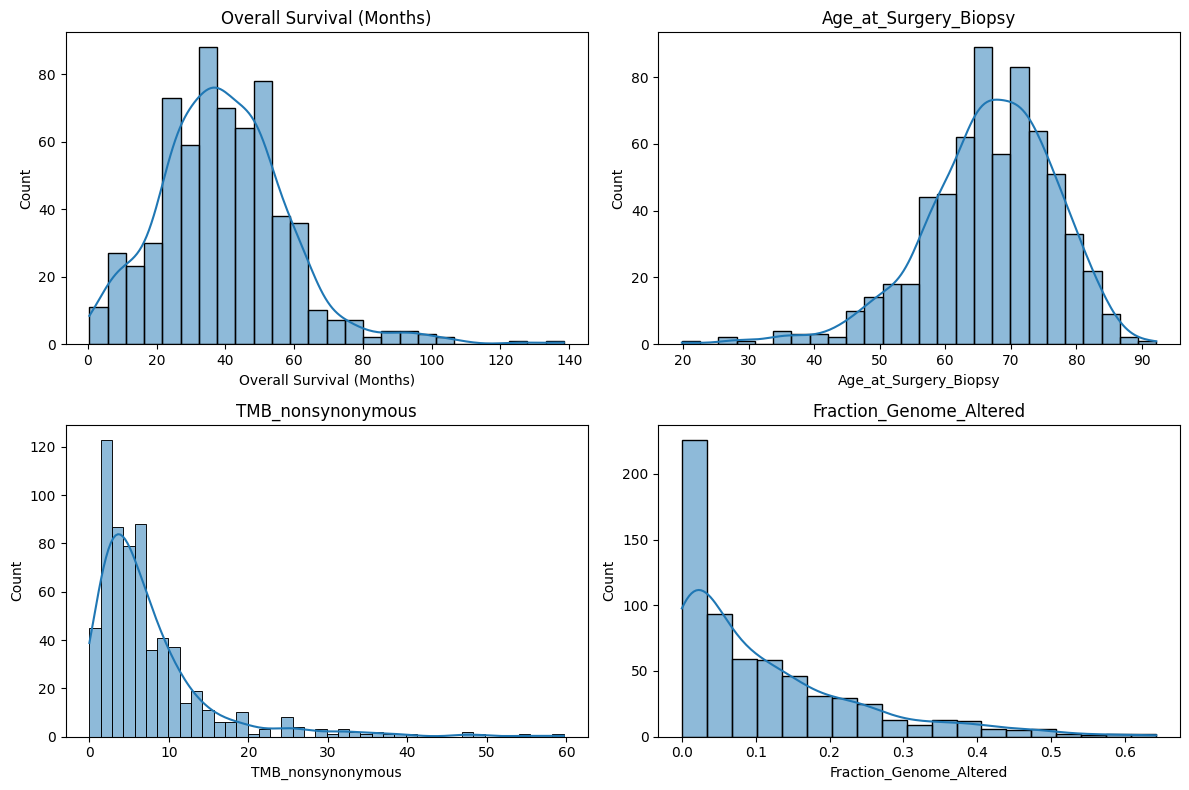

In [18]:
# Plot distribusi numerik
num_vars = [
    "Overall Survival (Months)",
    "Age_at_Surgery_Biopsy",
    "TMB_nonsynonymous",
    "Fraction_Genome_Altered"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(num_vars):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

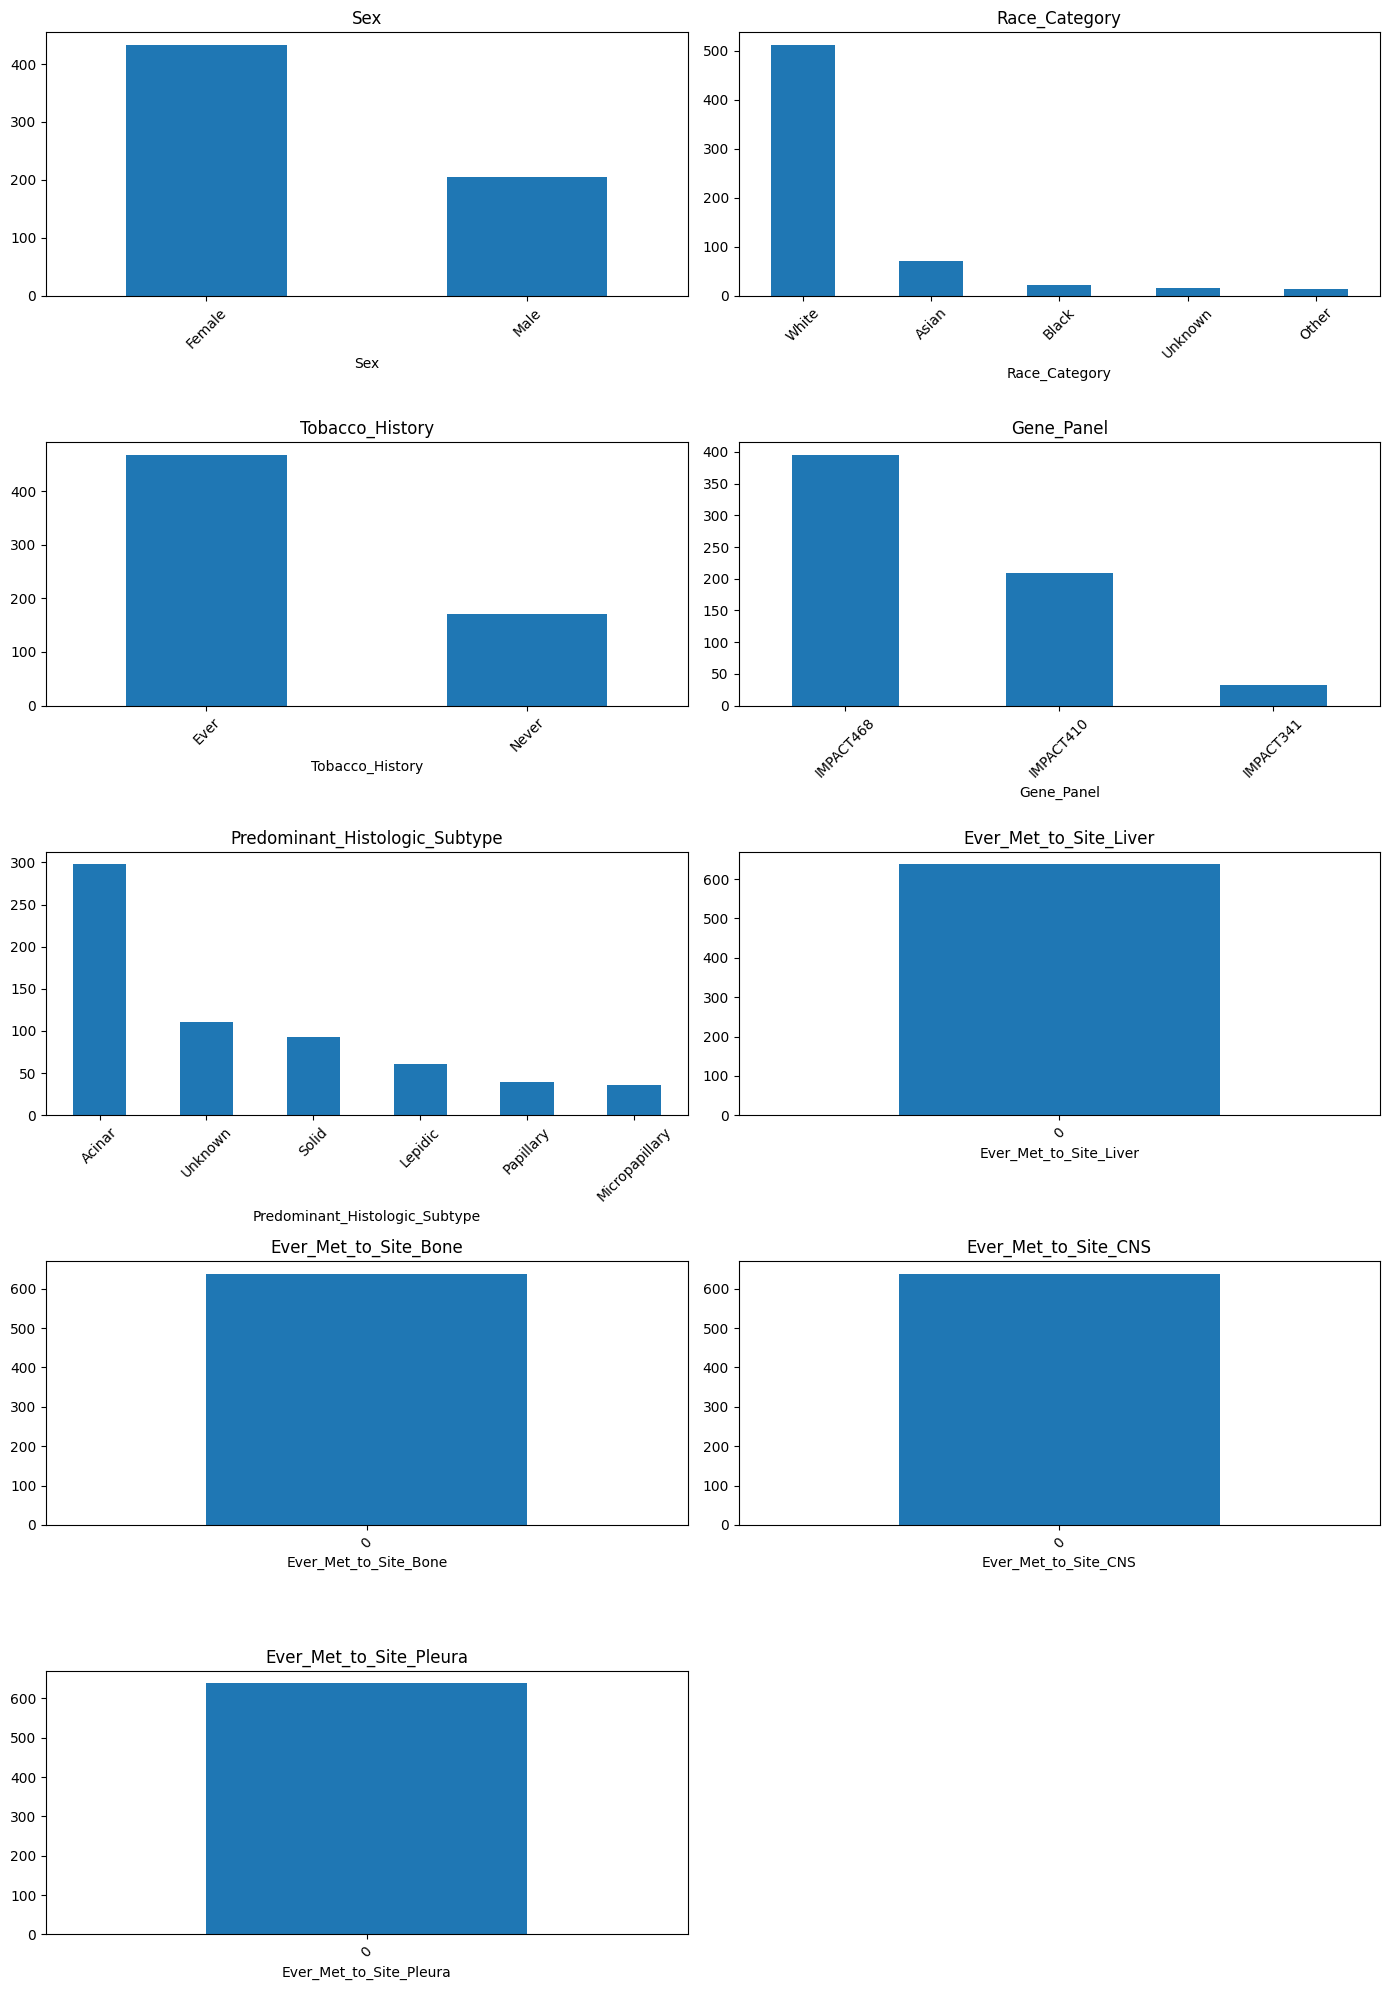

In [19]:
# Plot distribusi kategorikal
cat_vars = [
    "Sex", "Race_Category", "Tobacco_History",
    "Gene_Panel", "Predominant_Histologic_Subtype"
] + met_sites

n_cols = 2
n_rows = int(np.ceil(len(cat_vars) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    df_raw[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Kaplan Meier

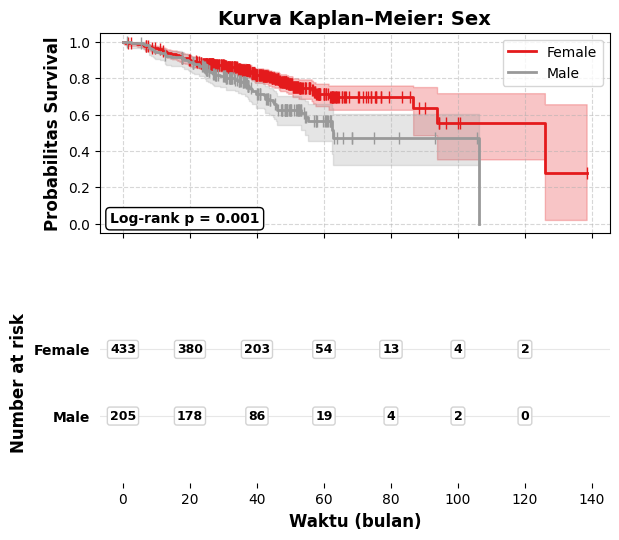

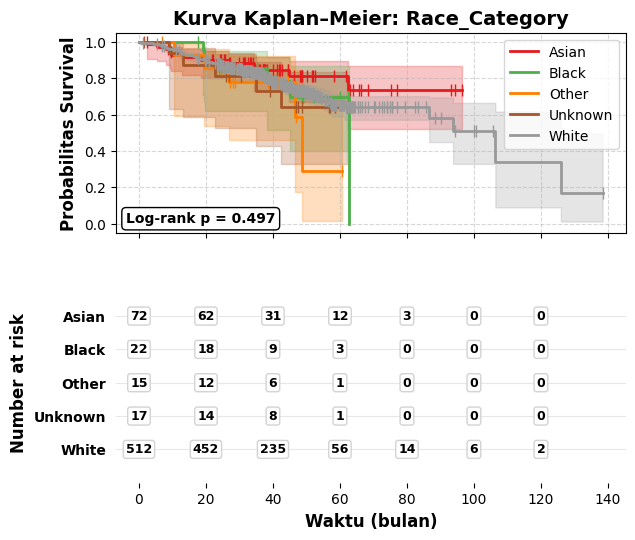

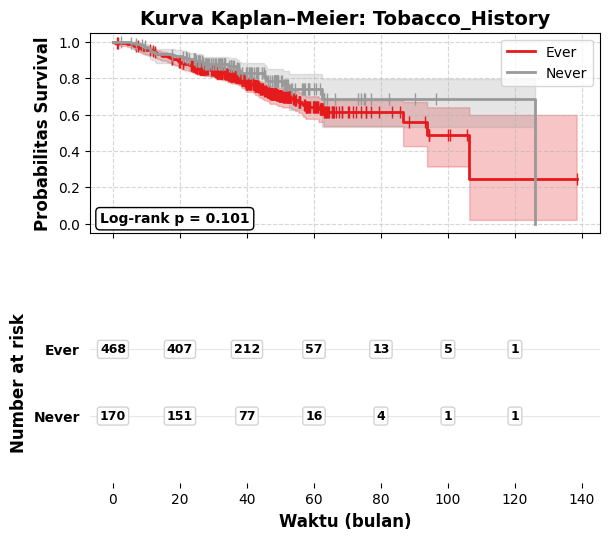

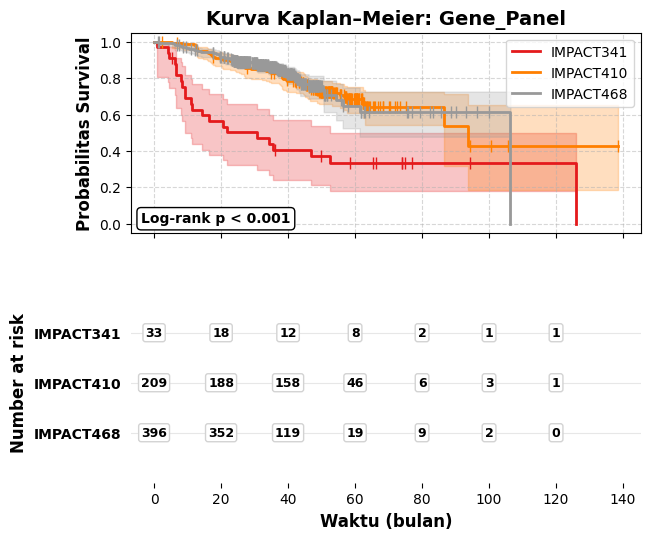

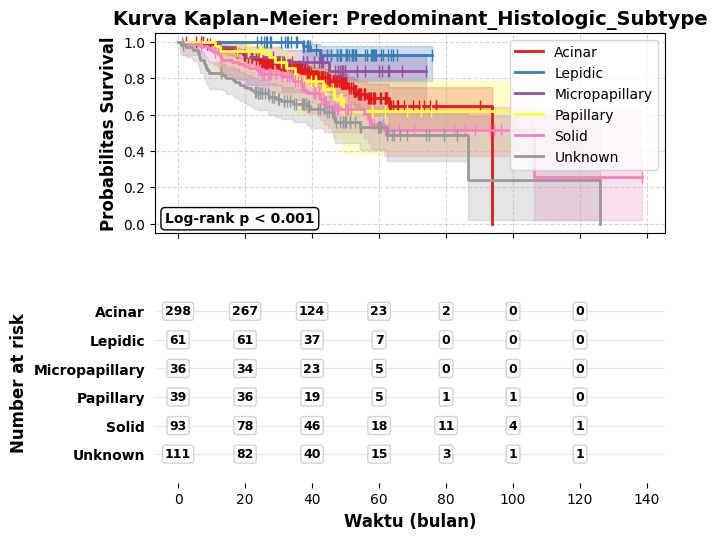

In [21]:
# Daftar variabel kategorikal
categorical_vars = [
    "Sex",
    "Race_Category",
    "Tobacco_History",
    "Gene_Panel",
    "Predominant_Histologic_Subtype",
]

# Loop tiap variabel
for var in categorical_vars:
    if var not in df.columns:
        print(f"Kolom {var} tidak ditemukan. Lewati.")
        continue

    df_var = df.dropna(subset=[var]).copy()
    unique_vals = df_var[var].dropna().unique()
    if len(unique_vals) < 2:
        print(f"Variabel {var} hanya punya 1 kategori. Lewati.")
        continue

    # Siapkan figure dan axes
    fig = plt.figure(figsize=(6, 6))
    ax1 = plt.subplot(2, 1, 1)  # survival curve
    ax2 = plt.subplot(2, 1, 2, sharex=ax1)  # number at risk table

    # Buat palet warna yang konsisten
    colors = plt.cm.Set1(np.linspace(0, 1, len(unique_vals)))

    kmf_list = []
    labels = []

    # Fit dan plot KM untuk setiap kelompok
    for idx, group in enumerate(sorted(unique_vals)):
        mask = df_var[var] == group
        if mask.sum() == 0:
            continue
        durations = df_var.loc[mask, "Overall Survival (Months)"]
        events = df_var.loc[mask, "Overall Survival Status"]

        kmf = KaplanMeierFitter()
        kmf.fit(durations, event_observed=events, label=str(group))
        kmf_list.append(kmf)
        labels.append(str(group))

        kmf.plot_survival_function(
            ax=ax1,
            ci_show=True,
            show_censors=True,
            color=colors[idx],
            censor_styles={"marker": "|", "ms": 8, "mec": colors[idx]},
            linewidth=2
        )

    # === HITUNG NUMBER AT RISK ===
    # Gunakan timepoints yang sesuai dengan data 
    max_time = df_var["Overall Survival (Months)"].max()
    timepoints = np.arange(0, int(max_time) + 20, 20)  # interval 20 bulan
    timepoints = timepoints[timepoints <= max_time]

    # Hitung jumlah pasien yang masih berisiko pada setiap timepoint
    risk_table = []
    for kmf in kmf_list:
        n_risk = []
        for t in timepoints:
            n = ((df_var["Overall Survival (Months)"] >= t) & (df_var[var] == kmf._label)).sum()
            n_risk.append(n)
        risk_table.append(n_risk)

    # Plot tabel number at risk
    ax2.set_ylim(0, len(kmf_list) + 1)
    ax2.set_yticks(range(len(kmf_list), 0, -1))
    ax2.set_yticklabels(labels, fontsize=10, fontweight='bold')
    ax2.set_xlabel("Waktu (bulan)", fontsize=12, fontweight='bold')
    ax2.set_ylabel("Number at risk", fontsize=12, fontweight='bold')
    ax2.set_frame_on(False)
    ax2.tick_params(left=False, top=False, right=False, bottom=True, labelsize=10)

    # Tambahkan garis grid horizontal tipis
    ax2.grid(axis='y', linestyle='-', alpha=0.3)

    # Tampilkan angka number at risk
    for i, n_risk in enumerate(risk_table):
        for j, t in enumerate(timepoints):
            ax2.text(t, len(kmf_list) - i, str(int(n_risk[j])), 
                     ha="center", va="center", fontsize=9, fontweight='bold',
                     bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.2'))

    # === UJI LOG-RANK ===
    if len(unique_vals) == 2:
        groups = sorted(unique_vals)
        mask1 = df_var[var] == groups[0]
        mask2 = df_var[var] == groups[1]
        t1 = df_var.loc[mask1, "Overall Survival (Months)"]
        e1 = df_var.loc[mask1, "Overall Survival Status"]
        t2 = df_var.loc[mask2, "Overall Survival (Months)"]
        e2 = df_var.loc[mask2, "Overall Survival Status"]
        lr = logrank_test(t1, t2, event_observed_A=e1, event_observed_B=e2)
        p_val = lr.p_value
    else:
        lr = multivariate_logrank_test(
            df_var["Overall Survival (Months)"],
            df_var[var],
            df_var["Overall Survival Status"]
        )
        p_val = lr.p_value

    # Format p-value
    if p_val < 0.001:
        p_text = "Log-rank p < 0.001"
    else:
        p_text = f"Log-rank p = {p_val:.3f}"

    # Tambahkan teks p-value di plot (kotak putih di pojok kiri atas)
    ax1.text(0.02, 0.05, p_text, transform=ax1.transAxes,
             fontsize=10, fontweight='bold',
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

    # Judul dan legenda
    ax1.set_title(f"Kurva Kaplan–Meier: {var}", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Probabilitas Survival", fontsize=12, fontweight='bold')
    ax1.set_xlabel("")
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend(loc='upper right', fontsize=10)

    # Sesuaikan margin dan spacing
    plt.subplots_adjust(hspace=0.25, left=0.1, right=0.95, top=0.9, bottom=0.15)
    plt.show()

## Regresi Cox

In [21]:
from lifelines import CoxPHFitter

# Siapkan dataframe untuk analisis

# Hapus kolom konstan
df_encoded = df_encoded.loc[:, df_encoded.nunique() > 1]
df_clean = df_encoded.copy()
duration_col = "Overall Survival (Months)"
event_col = "Overall Survival Status"

# List variabel prediktor (kecuali durasi dan event)
covariates = [c for c in df_clean.columns if c not in [duration_col, event_col]]

# Buat dataframe untuk menyimpan hasil univariat
univ_data = df_clean[[duration_col, event_col] + covariates].copy()

selected_vars = []
print("=== HASIL SELEKSI UNIVARIAT (p-value < 0.10) ===")
print(f"{'Variabel':<40} {'HR':<10} {'p-value':<10} {'Status'}")
print("-" * 80)

for var in covariates:
    # Cek apakah data bervariasi?
    if df_clean[var].nunique() < 2:
        # print(f"Skip {var}: Nilai konstan (varians 0)")
        continue
    
    # Cek jika kejadian terlalu sedikit (<5 kasus)
    if df_clean[var].value_counts().min() < 5 and df_clean[var].nunique() == 2:
        # print(f"Skip {var}: Kasus terlalu sedikit (<5)")
        continue

    try:
        cph = CoxPHFitter()
        subset = df_clean[[var, duration_col, event_col]].dropna()
        cph.fit(subset, duration_col=duration_col, event_col=event_col)
        
        p_val = cph.summary.loc[var, "p"]
        hr = cph.summary.loc[var, "exp(coef)"]
        
        if p_val < 0.10:
            selected_vars.append(var)
            print(f"{var:<40} {hr:.4f}     {p_val:.4f}     Lolos")
            
    except Exception as e:
        pass # Skip variabel yang error 

print(f"\nTotal variabel terpilih: {len(selected_vars)}")

=== HASIL SELEKSI UNIVARIAT (p-value < 0.10) ===
Variabel                                 HR         p-value    Status
--------------------------------------------------------------------------------
TMB_nonsynonymous                        1.0188     0.0246     Lolos
Fraction_Genome_Altered                  5.0508     0.0030     Lolos
Sex_Male                                 1.6772     0.0016     Lolos
Gene_Panel_IMPACT468                     0.7379     0.0703     Lolos
Predominant_Histologic_Subtype_Lepidic   0.1549     0.0014     Lolos
Predominant_Histologic_Subtype_Solid     1.4010     0.0928     Lolos
Predominant_Histologic_Subtype_Unknown   2.3424     0.0000     Lolos

Total variabel terpilih: 7


In [22]:
# Fit Model Multivariat
cph_multi = CoxPHFitter()
try:
    cph_multi.fit(df_clean[selected_vars + [duration_col, event_col]], 
                  duration_col=duration_col, event_col=event_col)
    
    c_index = cph_multi.concordance_index_
    print(f"\n=== MODEL MULTIVARIAT AWAL ===")
    print(f"C-index: {c_index:.4f}")
    if c_index > 0.7: print("Interpretasi: Model Baik.")
    
except Exception as e:
    print("Error fitting multivariat:", e)

print("\n=== RINGKASAN MODEL MULTIVARIAT ===")
print(cph_multi.summary)    


=== MODEL MULTIVARIAT AWAL ===
C-index: 0.6807

=== RINGKASAN MODEL MULTIVARIAT ===
                                            coef  exp(coef)  se(coef)  \
covariate                                                               
TMB_nonsynonymous                       0.008766   1.008805  0.008640   
Fraction_Genome_Altered                 1.126841   3.085893  0.558002   
Sex_Male                                0.464617   1.591405  0.164453   
Gene_Panel_IMPACT468                   -0.347298   0.706595  0.168402   
Predominant_Histologic_Subtype_Lepidic -1.492401   0.224832  0.590277   
Predominant_Histologic_Subtype_Solid    0.372216   1.450946  0.221655   
Predominant_Histologic_Subtype_Unknown  0.841025   2.318742  0.190432   

                                        coef lower 95%  coef upper 95%  \
covariate                                                                
TMB_nonsynonymous                            -0.008168        0.025701   
Fraction_Genome_Altered            

In [23]:
print("\n=== UJI ASUMSI PH ===")
# check_assumptions otomatis melakukan uji Schoenfeld
results = cph_multi.check_assumptions(df_clean[selected_vars + [duration_col, event_col]], 
                                      p_value_threshold=0.05, show_plots=False)

# Catatan: Perhatikan output. Variabel dengan p < 0.05 melanggar PH.


=== UJI ASUMSI PH ===
The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 638 total observations, 483 right-censored observations>
         test_name = proportional_hazard_test

---
                                             test_statistic      p  -log2(p)
Fraction_Genome_Altered                km              0.01   0.94      0.09
                                       rank            0.00   0.98      0.03
Gene_Panel_IMPACT468                   km              2.08   0.15      2.75
                                       rank            2.22   0.14      2.87
Predominant_Histologic_Subtype_Lepidic km              0.57   0.45      1.15
                                       rank            1.30   0.26      1.97
Predominant_Histologic_Subtype_Solid   km              0.89   0.35      1.53
                                       rank            0.79   0.37      1.42
Predominant_Histologic_Subtype_Unknown km              5.26   0.02      5.52
                                       rank           10.24 <0.005      9.50
Sex_Male                               km              1.79   0.18      2.47
                                       rank            2.34   0.13      2.99
TMB_nonsynonymous                      km              0.05   0.81      0.30
                                       rank            0.04   0.83      0.26



1. Variable 'Predominant_Histologic_Subtype_Unknown' failed the non-proportional test: p-value is 0.0014.

   Advice: with so few unique values (only 2), you can include
`strata=['Predominant_Histologic_Subtype_Unknown', ...]` in the call in `.fit`. See documentation in
link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



In [24]:
# SOLUSI PH VIOLATION: Masukkan variabel yang melanggar PH di sini


strata_vars = ['Predominant_Histologic_Subtype_Unknown'] 
# Cek apakah unknown atau stage ada di selected_vars
for var in selected_vars:
    if "Unknown" in var or "Stage" in var:  # Stratifikasi variabel Stage/Unknown
        strata_vars.append(var)

# Pastikan variabel strata ada di selected_vars
strata_vars = [v for v in strata_vars if v in selected_vars]

# Pisahkan prediktor (kovariat) dan strata
final_predictors = [v for v in selected_vars if v not in strata_vars]

print(f"\nMelakukan Stratifikasi pada: {strata_vars}")

# Fit Model Akhir
cph_final = CoxPHFitter()
cph_final.fit(df_clean, 
              duration_col=duration_col, 
              event_col=event_col, 
              strata=strata_vars, # Parameter stratifikasi
              formula=" + ".join(final_predictors)) # Formula eksplisit

print(f"Final C-index: {cph_final.concordance_index_:.4f}")


Melakukan Stratifikasi pada: ['Predominant_Histologic_Subtype_Unknown', 'Predominant_Histologic_Subtype_Unknown']
Final C-index: 0.6395


In [25]:
print("\n=== MODEL STRATIFIKASI AKHIR ===")
print(cph_final.summary)


=== MODEL STRATIFIKASI AKHIR ===
                                            coef  exp(coef)  se(coef)  \
covariate                                                               
TMB_nonsynonymous                       0.008390   1.008426  0.008807   
Fraction_Genome_Altered                 1.092095   2.980510  0.563725   
Sex_Male                                0.464282   1.590872  0.164874   
Gene_Panel_IMPACT468                   -0.354218   0.701722  0.168213   
Predominant_Histologic_Subtype_Lepidic -1.519192   0.218889  0.590370   
Predominant_Histologic_Subtype_Solid    0.375478   1.455687  0.223116   

                                        coef lower 95%  coef upper 95%  \
covariate                                                                
TMB_nonsynonymous                            -0.008870        0.025651   
Fraction_Genome_Altered                      -0.012787        2.196976   
Sex_Male                                      0.141135        0.787429   
Gene_Panel_

In [26]:
# Buat Tabel Laporan
summary_df = cph_final.summary.reset_index()
summary_df = summary_df.rename(columns={'covariate': 'Variabel', 'p': 'p-value', 'exp(coef)': 'HR'})

# Tambah Interpretasi Tekstual
def interpretasi(row):
    if row['p-value'] > 0.05: return "Tidak Signifikan"
    eff = (row['HR'] - 1) * 100
    if eff > 0: return f"Meningkatkan risiko {abs(eff):.1f}%"
    return f"Menurunkan risiko {abs(eff):.1f}%"

summary_df['Interpretasi'] = summary_df.apply(interpretasi, axis=1)
final_table = summary_df[['Variabel', 'HR', 'p-value', 'Interpretasi']]

print("\n=== TABEL UJI HIPOTESIS AKHIR ===")
pd.set_option('display.max_colwidth', 100)
display(final_table.sort_values('p-value'))

# Kesimpulan 
print("\n=== KESIMPULAN ===")
signifikan = final_table[final_table['p-value'] < 0.05]
if len(signifikan) > 0:
    print("Faktor-faktor berikut secara independen memengaruhi kelangsungan hidup pasien (p<0.05):")
    for i, row in signifikan.iterrows():
        print(f"- {row['Variabel']}: {row['Interpretasi']}")
else:
    print("Tidak ditemukan faktor risiko yang signifikan secara statistik.")


=== TABEL UJI HIPOTESIS AKHIR ===


,Variabel,HR,p-value,Interpretasi
2,Sex_Male,1.590872,0.004863,Meningkatkan risiko 59.1%
4,Predominant_Histologic_Subtype_Lepidic,0.218889,0.010074,Menurunkan risiko 78.1%
3,Gene_Panel_IMPACT468,0.701722,0.035225,Menurunkan risiko 29.8%
1,Fraction_Genome_Altered,2.980510,0.052711,Tidak Signifikan
5,Predominant_Histologic_Subtype_Solid,1.455687,0.092398,Tidak Signifikan
0,TMB_nonsynonymous,1.008426,0.340725,Tidak Signifikan



=== KESIMPULAN ===
Faktor-faktor berikut secara independen memengaruhi kelangsungan hidup pasien (p<0.05):
- Sex_Male: Meningkatkan risiko 59.1%
- Gene_Panel_IMPACT468: Menurunkan risiko 29.8%
- Predominant_Histologic_Subtype_Lepidic: Menurunkan risiko 78.1%


In [30]:
print(final_table)

                                 Variabel        HR   p-value  \
0                       TMB_nonsynonymous  1.008426  0.340725   
1                 Fraction_Genome_Altered  2.980510  0.052711   
2                                Sex_Male  1.590872  0.004863   
3                    Gene_Panel_IMPACT468  0.701722  0.035225   
4  Predominant_Histologic_Subtype_Lepidic  0.218889  0.010074   
5    Predominant_Histologic_Subtype_Solid  1.455687  0.092398   

                Interpretasi  
0           Tidak Signifikan  
1           Tidak Signifikan  
2  Meningkatkan risiko 59.1%  
3    Menurunkan risiko 29.8%  
4    Menurunkan risiko 78.1%  
5           Tidak Signifikan  


## AIC & BIC

In [ ]:
# UJI KELAYAKAN MODEL: AIC & BIC

def model_selection_metrics(cph_model, n_obs):
    """
    Menghitung AIC dan BIC untuk model Cox Proportional Hazards
    """
    log_likelihood = cph_model.log_likelihood_
    k = cph_model.params_.shape[0]  # jumlah parameter
    
    aic = -2 * log_likelihood + 2 * k
    bic = -2 * log_likelihood + k * np.log(n_obs)
    
    return aic, bic


# Jumlah observasi (harus konsisten dengan data yang digunakan saat fitting)
n_obs = df_clean.shape[0]

# Model 1: Multivariate Cox Regression (tanpa stratifikasi)
aic_multi, bic_multi = model_selection_metrics(cph_multi, n_obs)

# Model 2: Final Cox Regression dengan Stratifikasi
aic_final, bic_final = model_selection_metrics(cph_final, n_obs)

# Tabel Ringkasan Kelayakan Model
df_model_kelayakan = pd.DataFrame({
    "Model": [
        "Multivariate Cox Regression",
        "Final Cox Regression dengan Stratifikasi"
    ],
    "AIC": [
        round(aic_multi, 2),
        round(aic_final, 2)
    ],
    "BIC": [
        round(bic_multi, 2),
        round(bic_final, 2)
    ],
    "C-Index": [
        round(cph_multi.concordance_index_, 4),
        round(cph_final.concordance_index_, 4)
    ]
})

df_model_kelayakan


,Model,AIC,BIC,C-Index
0,Multivariate Cox Regression,1782.23,1813.43,0.6807
1,Final Cox Regression dengan Stratifikasi,1595.54,1622.29,0.6395
